# Stroboscopic Sensing — every experiment, one notebook

**Claim under test.** A < 100 k-parameter latent-oscillator world model that decides *where in a
physiological cycle* to fire an expensive sensor (PPG / respiration belt / ECG) can match dense-sampling
accuracy at a small fraction of the bursts, and beats threshold / event-triggered baselines **during motion**,
not only at rest.

**What this notebook does** (all code lives in the `strobo` package, this notebook only orchestrates):

1. loads PPG-DaLiA, WESAD, UCI-HAR and MIT-BIH from `/kaggle/input` (falls back to a synthetic generator per
   dataset that is missing, so the notebook always runs end-to-end),
2. trains the stroboscopic model, three ablations and four classical baselines over leave-subjects-out folds,
   sweeping every method to a full accuracy-vs-bursts curve,
3. produces the primary rest/motion figure, the phase-histogram centrepiece, an animated GIF of the
   oscillators sampling a PPG trace, ablation and cross-task tables, the MIT-BIH fallback test, an int8 export
   and op count, and a one-image poster of everything.

**Pre-registered success criterion** (from the plan): at 1 burst/beat during motion HR MAE ≤ 3 bpm while every
baseline is ≥ 5 bpm at the same burst count, and ≥ 3× fewer bursts than IMU-gated sampling at matched 2 bpm.
The notebook prints PASS/FAIL against this — either outcome is reported.

**Runtime.** `MODE = "quick"` ≈ 1 GPU-hour on a T4 (2 folds, short sweeps, 4 epochs); `MODE = "full"` ≈ 8–10 h
(5 folds, full sweeps, 6 epochs) — run it as a Kaggle *background* job. `MODE = "demo"` runs on synthetic data
only in ~10 min on CPU. Results are appended to CSV so an interrupted run resumes.

In [1]:
# ---------------------------------------------------------------- settings
import os, sys, glob, json, time, subprocess, warnings
warnings.filterwarnings("ignore")

MODE      = os.environ.get("STROBO_MODE", "quick")      # demo | quick | full
REPO_URL  = "https://github.com/welu2027/stroboscopic"  # source of the `strobo` package
DATA_ROOT = "/kaggle/input"                              # searched recursively for the four datasets
OUT       = "/kaggle/working/results" if os.path.exists("/kaggle/working") else "results/notebook"
SEED      = 0
os.makedirs(OUT, exist_ok=True)

# make the package importable: local checkout > attached dataset > git clone
def _find_pkg():
    for cand in [".", "..", *glob.glob("/kaggle/input/*/"), *glob.glob("/kaggle/input/*/*/")]:
        if os.path.exists(os.path.join(cand, "strobo", "__init__.py")):
            return os.path.abspath(cand)
    subprocess.run(["git", "clone", "-q", REPO_URL, "/kaggle/working/stroboscopic"], check=True)
    return "/kaggle/working/stroboscopic"
PKG = _find_pkg(); sys.path.insert(0, PKG); print("strobo package at", PKG)
try:
    import wfdb
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wfdb", "imageio"], check=False)


strobo package at C:\Users\jayva\OneDrive\Documents\GitHub\stroboscopic


In [2]:
import numpy as np, pandas as pd, torch, yaml
from IPython.display import Image, display, HTML
from strobo.data import make_windows, make_synthetic_recordings
from strobo.data.recording import zscore_per_recording, ACT_REST, ACT_MOTION
from strobo.data.paths import find_all
from strobo.train import build_model, train_model, get_device, set_seed
from strobo.eval import run_inference, summarise, phase_histogram, fallback_metrics, example_trace, curve_at, bursts_for_mae, oscillator_locking
from strobo.experiments import run_suite, aggregate, headline, METHODS
from strobo.export import quantize_model_int8, int8_forward_check, op_report
from strobo import viz
viz.use_style()

cfg = yaml.safe_load(open(os.path.join(PKG, "configs/default.yaml")))
PRESET = {
    # max_train_windows caps the training set per fold (8 s windows, 4 s stride); the per-tick recurrent loop is
    # python-bound (~0.4 s per batch of 64 on a T4), so this is what sets the runtime.
    "demo":  dict(epochs=6, warm_epochs=1, finetune_epochs=1, n_folds=2, max_folds=1, lam_e=[0.0, 1.0, 3.0, 10.0], classical=4, minutes=6.0, max_train_windows=600),
    "quick": dict(epochs=4, warm_epochs=1, finetune_epochs=1, n_folds=5, max_folds=2, lam_e=[0.0, 0.3, 1.0, 3.0, 10.0], classical=5, minutes=8.0, max_train_windows=5000),
    "full":  dict(epochs=5, warm_epochs=1, finetune_epochs=2, n_folds=5, max_folds=3, lam_e=[0.0, 0.1, 0.3, 1.0, 3.0, 10.0], classical=6, minutes=8.0, max_train_windows=9000),
}[MODE]
cfg["train"].update(epochs=PRESET["epochs"], warm_epochs=PRESET["warm_epochs"], finetune_epochs=PRESET["finetune_epochs"])
cfg["data"]["n_folds"] = PRESET["n_folds"]
dev = get_device(); set_seed(SEED)
print(f"MODE={MODE}  device={dev}  torch={torch.__version__}")
paths = find_all(DATA_ROOT) if MODE != "demo" else {k: None for k in ("ppg_dalia", "wesad", "uci_har", "mitbih")}
print(json.dumps(paths, indent=1))


MODE=demo  device=cpu  torch=2.13.0+cpu
{
 "ppg_dalia": null,
 "wesad": null,
 "uci_har": null,
 "mitbih": null
}


## 1. Data

All streams are put on a 32 Hz *tick* grid (the wrist-IMU rate). The expensive sensor keeps its native rate by
storing `k` samples per tick (PPG: 2). A **burst** is 4 ticks = 8 PPG samples = 125 ms, matching how a PPG
front-end wakes, settles and reads. Targets (HR, RMSSD) come from chest-ECG R-peaks; activity labels give the
rest / motion split. When a dataset is not attached, a synthetic stand-in with the same structure is generated
and clearly labelled as such.

In [3]:
def load_or_synth(name, loader, n_syn=6, **kw):
    """Load a real dataset if found, else synthesise; returns (recordings, is_synthetic)."""
    root = paths.get(name)
    if root:
        try:
            recs = loader(root, **kw); print(f"{name}: {len(recs)} recordings from {root}")
            return recs, False
        except Exception as e:
            print(f"{name}: failed to load ({e}); using synthetic stand-in")
    else:
        print(f"{name}: not found under {DATA_ROOT}; using synthetic stand-in")
    return make_synthetic_recordings(n_syn, minutes=PRESET["minutes"], seed=hash(name) % 1000), True

from strobo.data.dalia import load_dalia
recs_dalia, syn_dalia = load_or_synth("ppg_dalia", load_dalia, n_syn=6)
recs_dalia = [zscore_per_recording(r) for r in recs_dalia]
for r in recs_dalia[:3]: print("  ", r.summary())
W = make_windows(recs_dalia, cfg["data"]["window_s"], cfg["data"]["stride_s"])
print("windows:", W["cheap"].shape, "| subjects:", len(set(W["subject"])))


ppg_dalia: not found under /kaggle/input; using synthetic stand-in
   synthetic/syn00: 6.0 min @ 32 Hz, k=2, beats=468, rest=70%, motion=30%
   synthetic/syn01: 6.0 min @ 32 Hz, k=2, beats=464, rest=63%, motion=37%
   synthetic/syn02: 6.0 min @ 32 Hz, k=2, beats=594, rest=56%, motion=44%
windows: (534, 256, 3) | subjects: 6


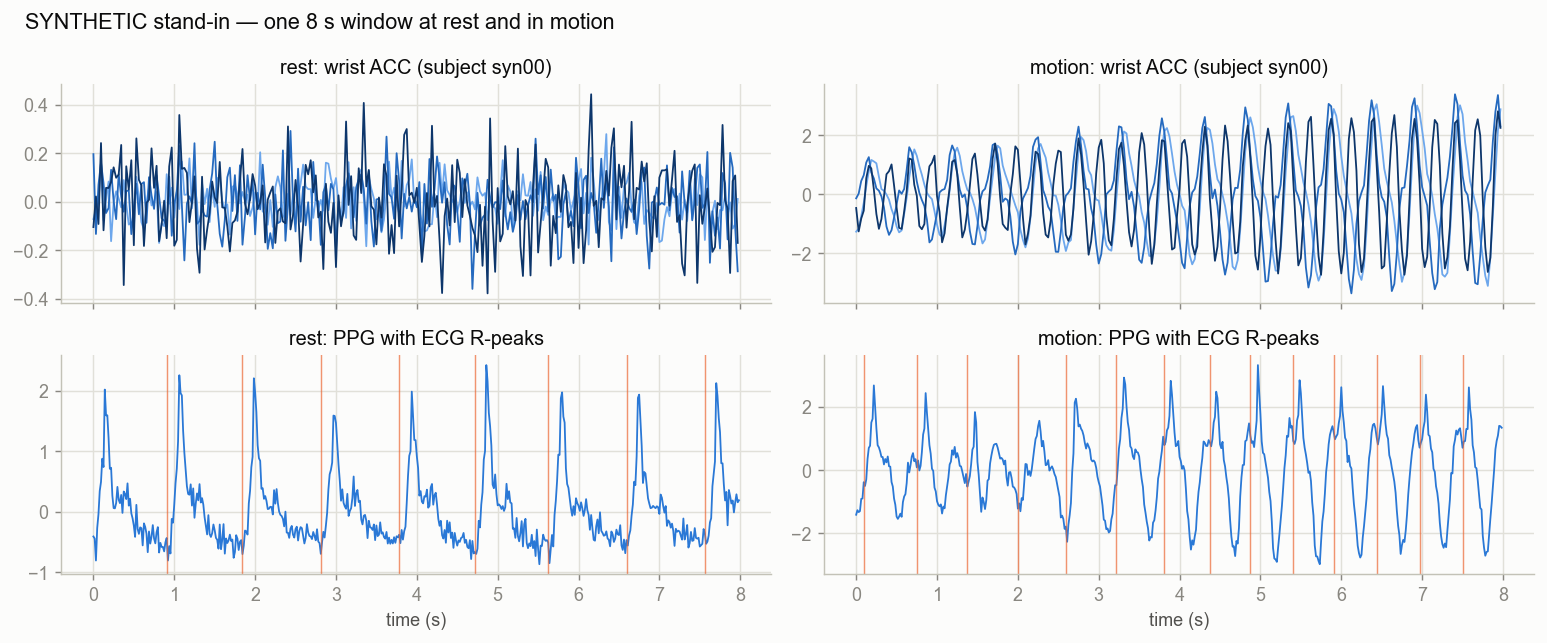

In [4]:
# a look at the raw signals: rest vs motion windows from one subject
import matplotlib.pyplot as plt
from strobo.data.windows import window_activity_mode
mode = window_activity_mode(W)
fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)
for col, (m, lab) in enumerate([(ACT_REST, "rest"), (ACT_MOTION, "motion")]):
    i = int(np.where(mode == m)[0][0]) if (mode == m).any() else 0
    t = np.arange(W["cheap"].shape[1]) / W["fs"]
    for j in range(3): axes[0, col].plot(t, W["cheap"][i, :, j], color=viz.SEQ_BLUE[2 + 2 * j], lw=1)
    axes[1, col].plot(np.repeat(t, 2) + np.tile([0, 1 / 64], t.size), W["expensive"][i].reshape(-1), color=viz.SERIES["ours"], lw=1)
    for b in np.where(W["beats"][i] > 0)[0]: axes[1, col].axvline(t[b], color=viz.SERIES["fixed_rate"], lw=0.8, alpha=0.7)
    axes[0, col].set_title(f"{lab}: wrist ACC (subject {W['subject'][i]})"); axes[1, col].set_title(f"{lab}: PPG with ECG R-peaks")
axes[1, 0].set_xlabel("time (s)"); axes[1, 1].set_xlabel("time (s)")
fig.suptitle(("SYNTHETIC stand-in — " if syn_dalia else "PPG-DaLiA — ") + "one 8 s window at rest and in motion", x=0.02, ha="left")
fig.tight_layout(); fig.savefig(f"{OUT}/fig0_data.png"); plt.show()


## 2. The model

Wrist ACC → causal conv encoder → 12 coupled Kuramoto oscillators (phase, frequency, amplitude, per-oscillator
waveform template) → **sampling head** that sees `[cos θ, sin θ]`, coherence, the last burst and time-since-last
→ Gumbel-straight-through fire decision → burst → decoder (2 × 64 MLP, Gaussian head). The **Fisher term**
rewards firing where the template slope `w'(θ)` is steep; the **coherence fallback** opens a dense-sampling gate
when the order parameter `r` drops below a learned threshold — both are trained, not rules.

{
 "params": 19598,
 "params_kb_int8": 19.138671875,
 "macs_per_tick_amortised": 7808,
 "macs_per_tick_peak": 19028,
 "decoder_every_ticks": 16,
 "transcendentals_per_tick": 248,
 "us_per_tick_m4_48mhz": 261.8666666666667,
 "budget_ok": true
}
{'encoder': 3312, 'oscillator': 1764, 'head': 1984, 'decoder': 11968, 'total': 19028}


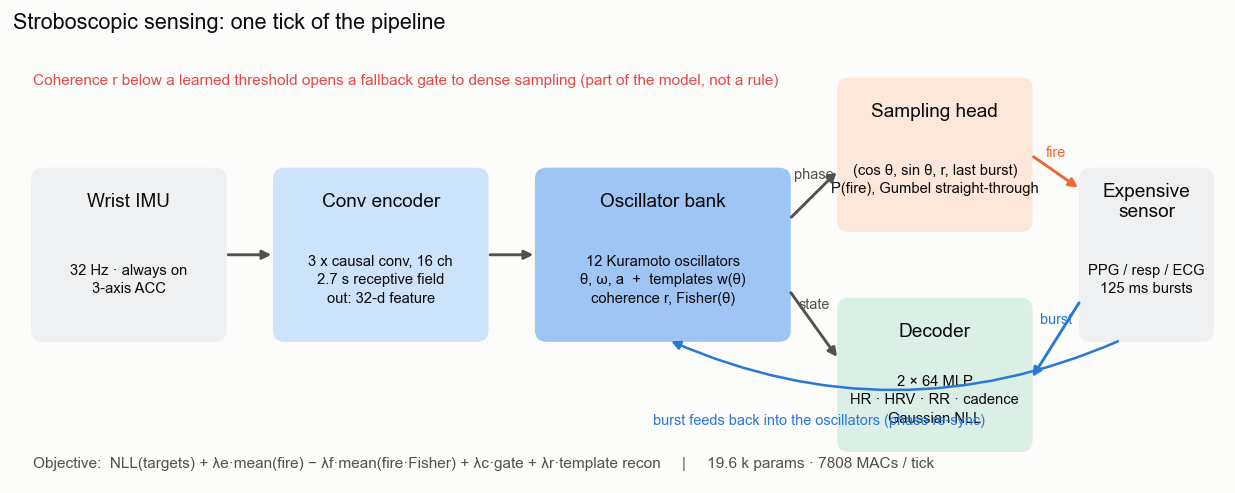

In [5]:
model0 = build_model(W, cfg["model"], "phase", True, True, np.arange(len(W["subject"])))
rep = op_report(model0)
print(json.dumps({k: v for k, v in rep.items() if k != "macs_breakdown"}, indent=1)); print(rep["macs_breakdown"])
fig = viz.architecture_figure(f"{OUT}/fig1_architecture.png", rep["params"], rep["macs_per_tick_amortised"]); plt.show()


## 3. Main experiment: HR from sparse PPG, rest vs. motion

Eight methods, each swept to a full curve, leave-subjects-out folds. Classical baselines share a decoder that is
pre-trained on random fixed-rate masks and fine-tuned per setting; learned methods train end-to-end with the
sampling head. Every row is saved to `results.csv` as it finishes.

In [6]:
t0 = time.time()
df, kept = run_suite(W, cfg, os.path.join(OUT, "dalia"), methods=list(METHODS), n_folds=PRESET["n_folds"],
                     lam_e_list=PRESET["lam_e"], max_folds=PRESET["max_folds"], device=dev,
                     classical_sweep_limit=PRESET["classical"], keep_models_for=("ours", "learned_threshold", "fixed_rate"),
                     max_train_windows=PRESET["max_train_windows"])
print(f"suite finished in {(time.time()-t0)/60:.1f} min; {len(df)} rows")
df.to_csv(f"{OUT}/dalia_results.csv", index=False)
agg = aggregate(df, "hr"); agg.to_csv(f"{OUT}/dalia_curves.csv", index=False)
agg[agg["mode"] == "motion"].sort_values(["method", "bursts_per_beat"]).head(20)


=== fold 0: test subjects ['syn03', 'syn02', 'syn05'] (267 train / 267 test windows)


[ours λe=0.0 f0] ep  0 tau=1.00 loss=1.040 nll=0.459 rate=0.031 recon=0.583 (17s)


[ours λe=0.0 f0] ep  1 tau=1.00 loss=0.986 nll=0.425 rate=0.082 recon=0.568 (17s)


[ours λe=0.0 f0] ep  2 tau=0.56 loss=0.889 nll=0.409 rate=0.089 recon=0.488 (15s)


[ours λe=0.0 f0] ep  3 tau=0.32 loss=0.820 nll=0.341 rate=0.104 recon=0.488 (15s)


...

[imu_gated {'period_rest_s': 2.0, 'period_motion_s': 1.0} f0] ep  0 tau=0.10 loss=0.747 nll=0.195 rate=0.023 recon=0.552 (13s)


    imu_gated          {'period_rest_s': 2.0, 'period_motion_s': 1.0} bpb=0.53 mae_hr=14.33 mae_rmssd=7.67


[imu_gated {'period_rest_s': 4.0, 'period_motion_s': 2.0} f0] ep  0 tau=0.10 loss=0.731 nll=0.192 rate=0.012 recon=0.540 (13s)


    imu_gated          {'period_rest_s': 4.0, 'period_motion_s': 2.0} bpb=0.24 mae_hr=14.13 mae_rmssd=7.49
suite finished in 39.9 min; 102 rows


,method,setting,mode,bursts_per_beat,duty,mae,mae_sd,n_folds
13,fixed_rate,"{""period_s"": 6.0}",motion,0.090974,0.020864,13.529160,NaN,1
10,fixed_rate,"{""period_s"": 3.0}",motion,0.181232,0.041564,16.653938,NaN,1
7,fixed_rate,"{""period_s"": 1.5}",motion,0.362464,0.083128,15.557197,NaN,1
4,fixed_rate,"{""period_s"": 0.75}",motion,0.727077,0.166749,16.965456,NaN,1
1,fixed_rate,"{""period_s"": 0.25}",motion,2.181232,0.500246,14.962728,NaN,1
25,imu_gated,"{""period_motion_s"": 2.0, ""period_rest_s"": 4.0}",motion,0.274355,0.062921,17.618147,NaN,1
22,imu_gated,"{""period_motion_s"": 1.0, ""period_rest_s"": 2.0}",motion,0.544413,0.124856,17.522470,NaN,1
19,imu_gated,"{""period_motion_s"": 0.5, ""period_rest_s"": 1.0}",motion,1.088825,0.249713,15.876247,NaN,1
16,imu_gated,"{""period_motion_s"": 0.25, ""period_rest_s"": 0.5}",motion,2.180516,0.500082,15.254102,NaN,1
37,kalman,"{""thr"": 1.4}",motion,0.363181,0.083292,15.282336,NaN,1


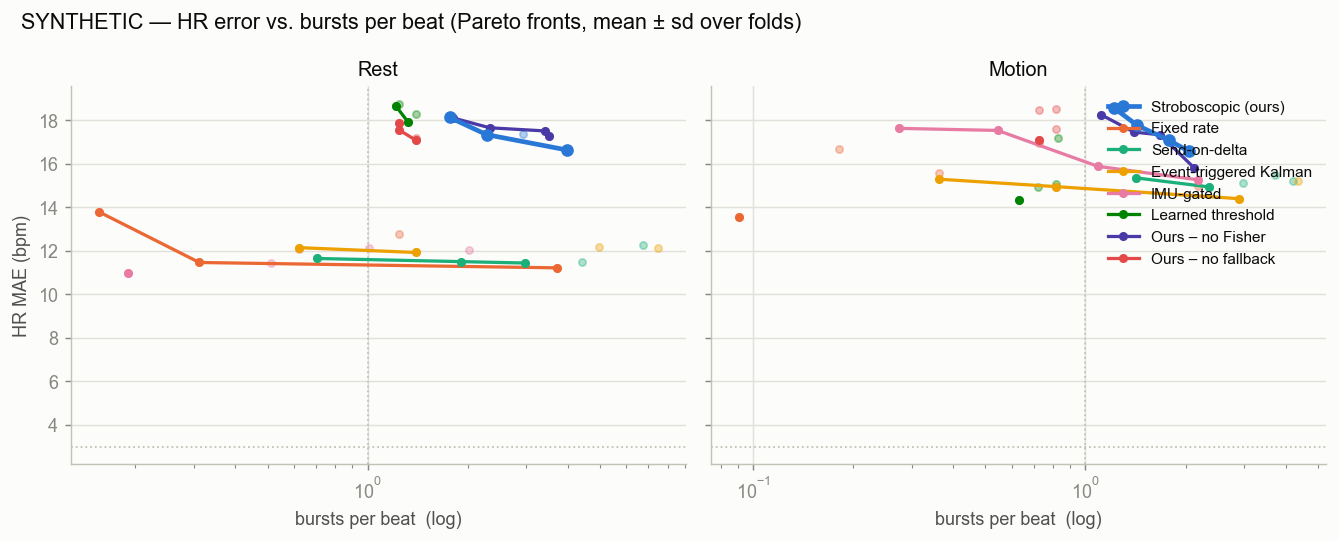

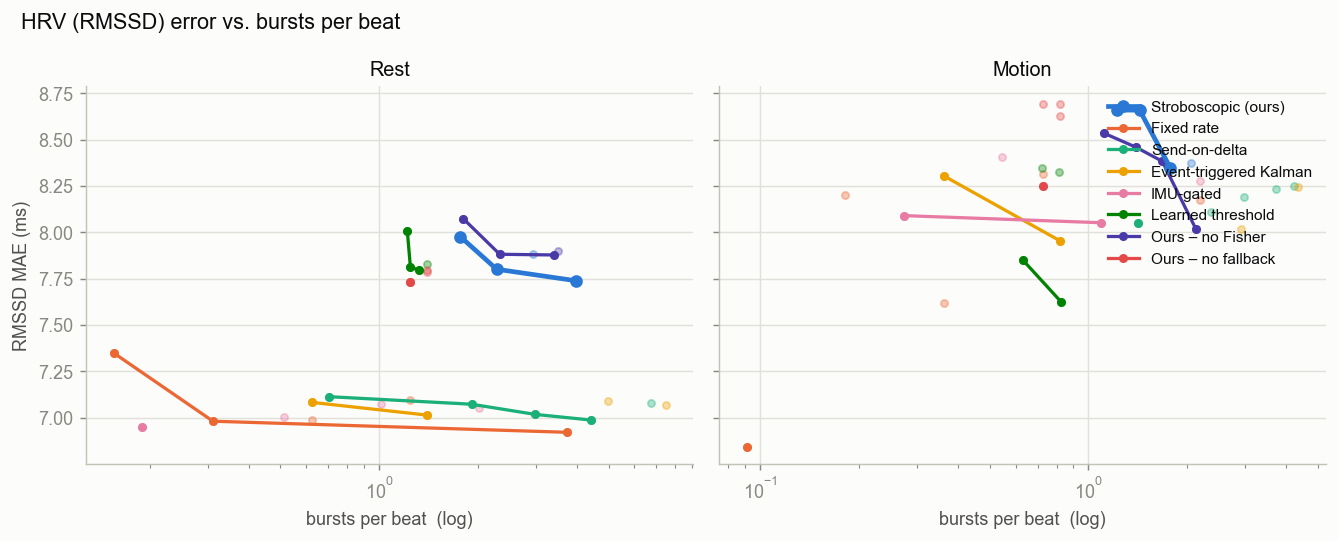

In [7]:
fig = viz.plot_curves(df, "hr", path=f"{OUT}/fig2_hr_curves.png", success=3.0,
                      title=("SYNTHETIC — " if syn_dalia else "PPG-DaLiA — ") + "HR error vs. bursts per beat (Pareto fronts, mean ± sd over folds)")
plt.show()
fig = viz.plot_curves(df, "rmssd", path=f"{OUT}/fig2b_hrv_curves.png", title="HRV (RMSSD) error vs. bursts per beat"); plt.show()


,mae@1.0bpb_rest,bpb@2.0mae_rest,mae@1.0bpb_motion,bpb@2.0mae_motion
method,,,,
ours,18.12,NaN,18.56,NaN
ours_no_fisher,18.10,NaN,18.25,NaN
ours_no_fallback,17.86,NaN,17.07,NaN
learned_threshold,18.63,NaN,14.34,NaN
fixed_rate,11.34,NaN,13.53,NaN
send_on_delta,11.59,NaN,15.34,NaN
kalman,12.01,NaN,14.85,NaN
imu_gated,10.96,NaN,16.08,NaN


criterion 1 (motion, 1 burst/beat): ours 18.56 bpm vs best baseline 13.53 bpm -> FAIL
criterion 2 (bursts for 2 bpm in motion): IMU-gated nan vs ours nan (nanx) -> FAIL
NOTE: computed on the synthetic stand-in, not on PPG-DaLiA.


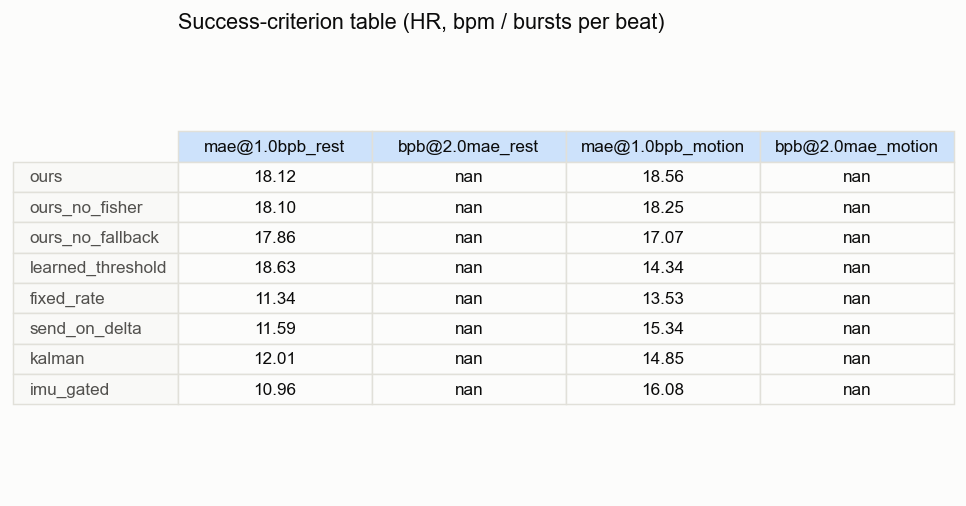

In [8]:
# ---- pre-registered success criterion
H = headline(df, "hr", at_bpb=1.0, at_mae=2.0)
display(H.round(2))
ours_motion = H.loc["ours", "mae@1.0bpb_motion"]
base_motion = H.drop(index=[m for m in H.index if m.startswith("ours")])["mae@1.0bpb_motion"]
imu_bpb, ours_bpb = H.loc["imu_gated", "bpb@2.0mae_motion"], H.loc["ours", "bpb@2.0mae_motion"]
crit1 = ours_motion <= 3.0 and (base_motion >= 5.0).all()
crit2 = np.isfinite(imu_bpb) and np.isfinite(ours_bpb) and imu_bpb / ours_bpb >= 3.0
print(f"criterion 1 (motion, 1 burst/beat): ours {ours_motion:.2f} bpm vs best baseline {base_motion.min():.2f} bpm -> {'PASS' if crit1 else 'FAIL'}")
print(f"criterion 2 (bursts for 2 bpm in motion): IMU-gated {imu_bpb:.2f} vs ours {ours_bpb:.2f} ({imu_bpb/ours_bpb if ours_bpb else np.nan:.1f}x) -> {'PASS' if crit2 else 'FAIL'}")
if syn_dalia: print("NOTE: computed on the synthetic stand-in, not on PPG-DaLiA.")
fig = viz.table_figure(H.round(2), f"{OUT}/fig3_headline_table.png", "Success-criterion table (HR, bpm / bursts per beat)"); plt.show()


## 4. Phase diagnostic — the qualitative centrepiece

Histogram of the ECG-referenced cardiac phase at which the trained policy fires. If the model does what we claim,
this is sharply peaked on the systolic upstroke at rest and shifts / broadens under motion (where gait-locked
artefact lands on the preferred phase). The mean resultant length `R` quantifies phase-locking (0 = uniform).

diagnostic model: ('ours', '{"lam_e": 10.0}') | bursts/beat: 1.43


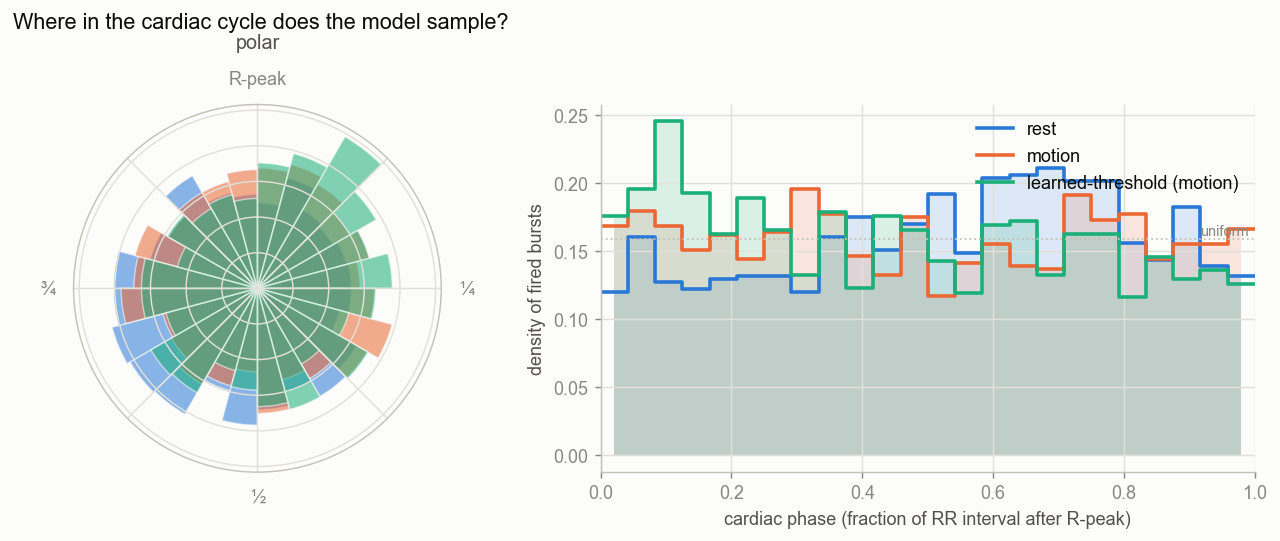

{'rest': {'R': 0.111, 'mean_phase_frac': 0.652, 'n': 1592}, 'motion': {'R': 0.026, 'mean_phase_frac': 0.056, 'n': 1698}, 'learned-threshold (motion)': {'R': 0.062, 'mean_phase_frac': 0.19, 'n': 1151}}
rest: best-locked oscillator #7 R=0.67 (harmonic 0.09); per-oscillator R=[0.4399999976158142, 0.2800000011920929, 0.18000000715255737, 0.05000000074505806, 0.14000000059604645, 0.4399999976158142, 0.6100000143051147, 0.6700000166893005, 0.6499999761581421, 0.4699999988079071, 0.36000001430511475, 0.27000001072883606]; mean f(Hz)=[0.1599999964237213, 0.17000000178813934, 0.20000000298023224, 0.20000000298023224, 0.3400000035762787, 0.6899999976158142, 0.8500000238418579, 1.0800000429153442, 1.2699999809265137, 1.4800000190734863, 1.8799999952316284, 2.549999952316284]
motion: best-locked oscillator #7 R=0.09 (harmonic 0.01); per-oscillator R=[0.05000000074505806, 0.05000000074505806, 0.029999999329447746, 0.019999999552965164, 0.029999999329447746, 0.05000000074505806, 0.07000000029802322,

In [9]:
def pick_kept(kept, method, prefer_bpb=1.0):
    """The kept fold-0 model of `method` whose all-ticks bursts/beat is closest to prefer_bpb."""
    c = [(abs(summarise(v["res"])["all"]["bursts_per_beat"] - prefer_bpb), k, v) for k, v in kept.items() if k[0] == method]
    return sorted(c, key=lambda x: x[0])[0][1:] if c else (None, None)
key, K = pick_kept(kept, "ours")
print("diagnostic model:", key, "| bursts/beat:", round(summarise(K["res"])["all"]["bursts_per_beat"], 2))
res = K["res"]
hists = {"rest": phase_histogram(res, "rest"), "motion": phase_histogram(res, "motion")}
_, Kthr = pick_kept(kept, "learned_threshold")
if Kthr: hists["learned-threshold (motion)"] = phase_histogram(Kthr["res"], "motion")
fig = viz.plot_phase_histogram(hists, f"{OUT}/fig4_phase_histogram.png"); plt.show()
print({k: dict(R=round(h["R"], 3), mean_phase_frac=round(h["mean_phase"] / (2 * np.pi), 3), n=h["n"]) for k, h in hists.items()})
# do the latent oscillators themselves lock to the cardiac cycle?  (mean resultant length of theta_i - ECG phase)
for mode in ("rest", "motion"):
    lk = oscillator_locking(res, mode)
    if lk: print(f"{mode}: best-locked oscillator #{lk['best_osc']} R={lk['best_R']:.2f} (harmonic {lk['best_R_harmonic']:.2f}); "
                 f"per-oscillator R={np.round(lk['R_per_osc'], 2).tolist()}; mean f(Hz)={np.round(lk['mean_omega_hz'], 2).tolist()}")


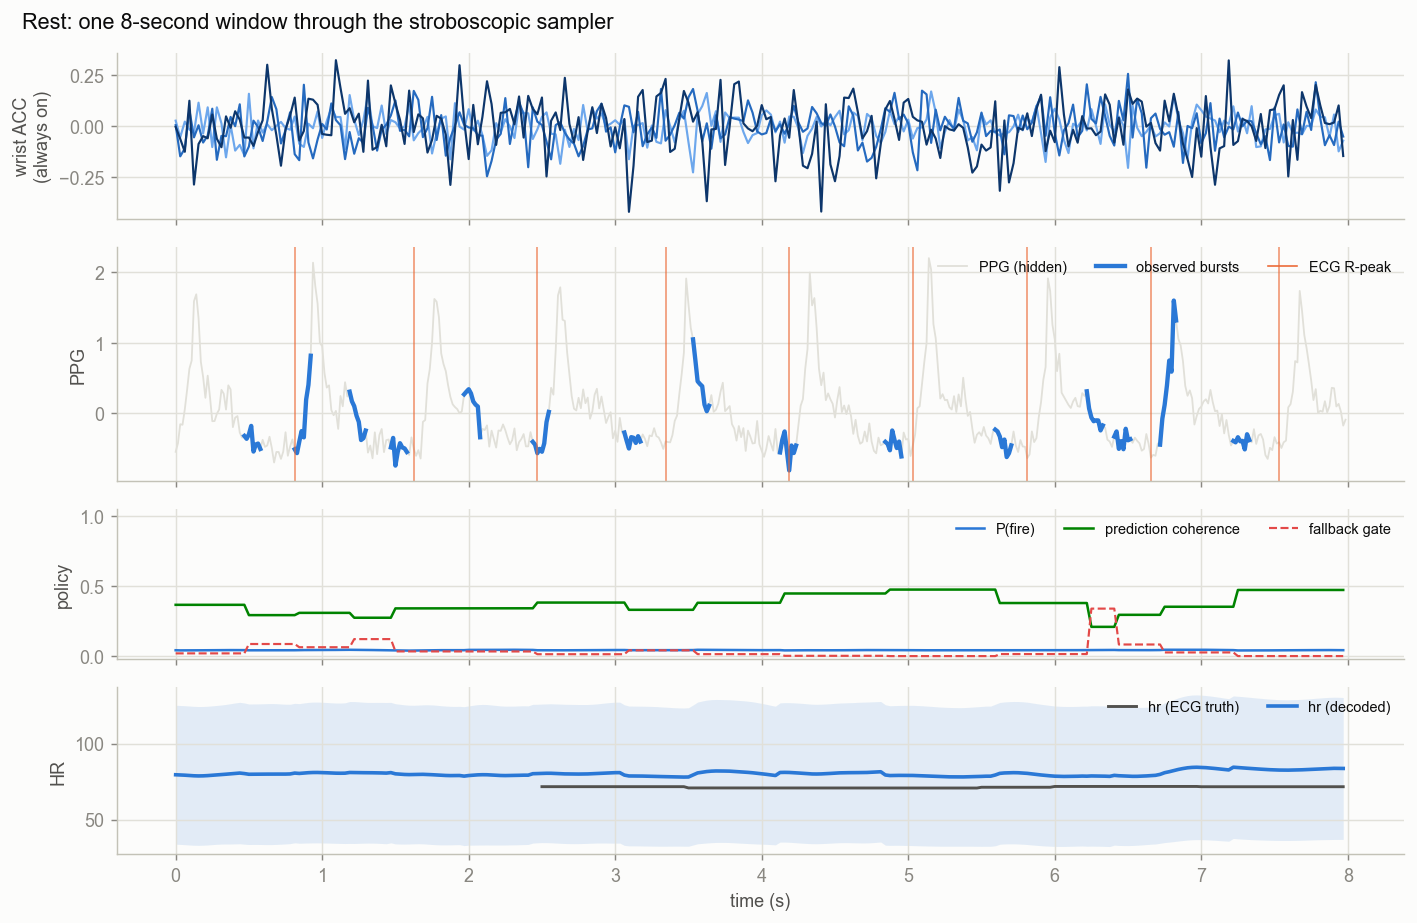

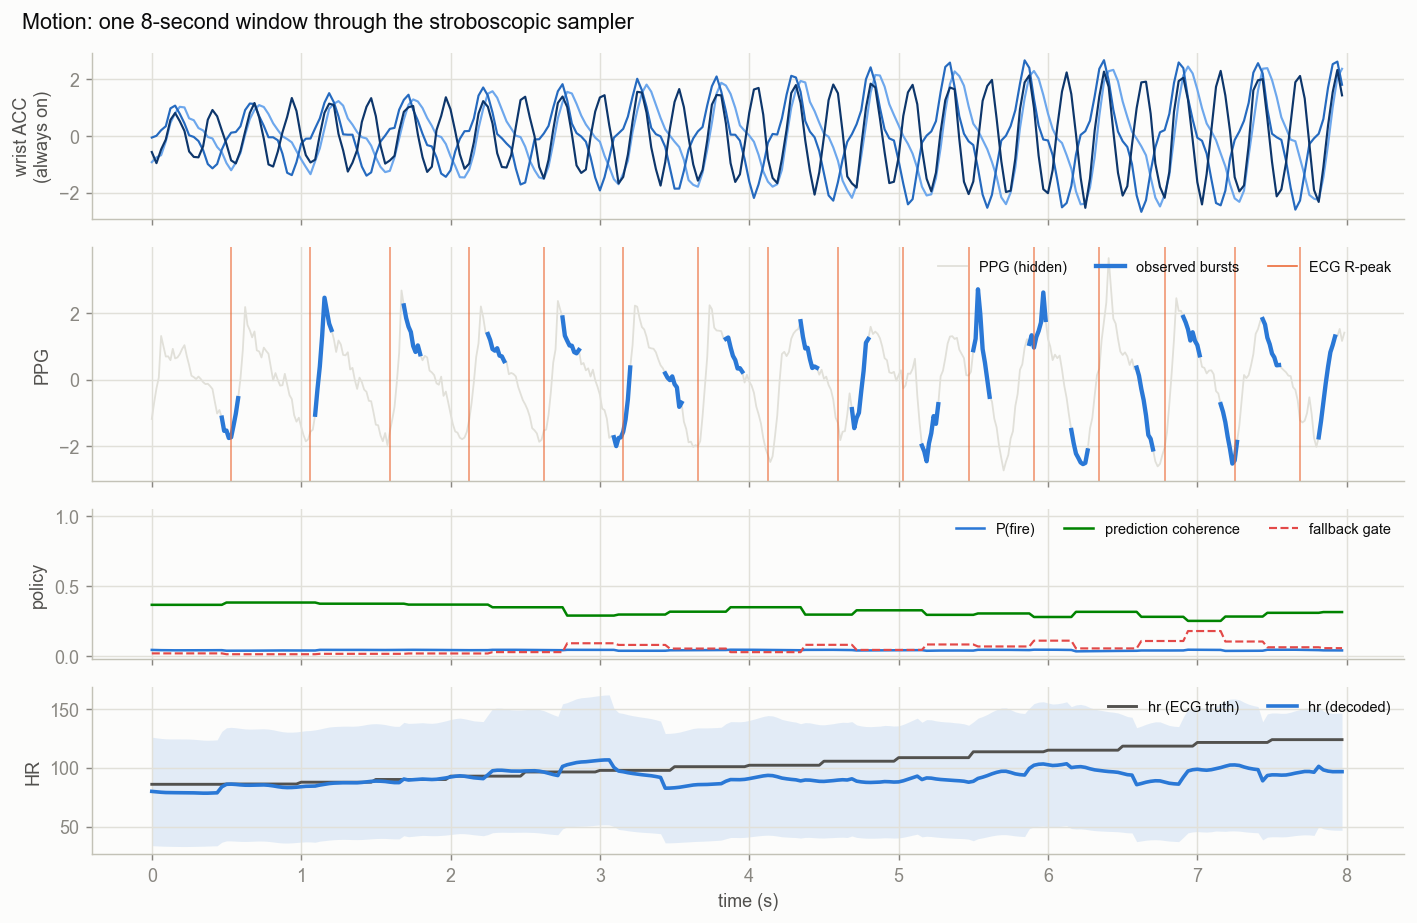

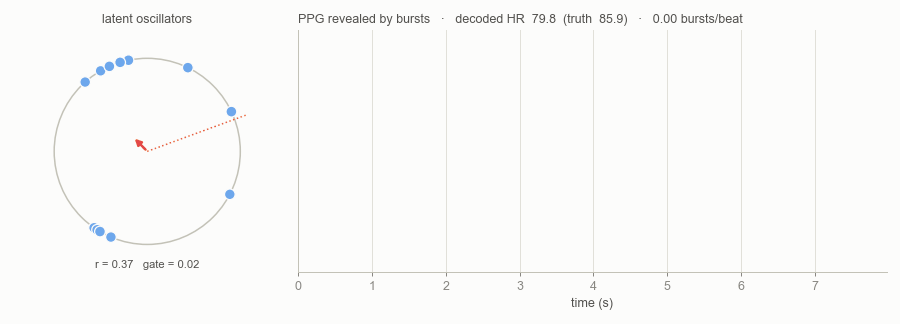

In [10]:
# one window through the sampler, plus the animation
i_mot = int(np.where((res["activity"] == ACT_MOTION).mean(1) > 0.8)[0][0]) if ((res["activity"] == ACT_MOTION).mean(1) > 0.8).any() else 0
i_rest = int(np.where((res["activity"] == ACT_REST).mean(1) > 0.8)[0][0]) if ((res["activity"] == ACT_REST).mean(1) > 0.8).any() else 1
fig = viz.plot_trace(example_trace(res, i_rest), f"{OUT}/fig5_trace_rest.png", "Rest: one 8-second window through the stroboscopic sampler"); plt.show()
fig = viz.plot_trace(example_trace(res, i_mot), f"{OUT}/fig5_trace_motion.png", "Motion: one 8-second window through the stroboscopic sampler"); plt.show()
gif = viz.make_animation(example_trace(res, i_mot), f"{OUT}/anim_oscillators_motion.gif", max_seconds=8.0)
display(Image(filename=gif))


## 5. Ablations

Same architecture, same folds: remove the Fisher reward, remove the coherence fallback, or hide the oscillator
phase from the sampling head (learned threshold). Numbers are HR MAE interpolated on each Pareto front.

,rest @0.5bpb,rest @1.0bpb,rest @2.0bpb,motion @0.5bpb,motion @1.0bpb,motion @2.0bpb,phase R (rest),phase R (motion)
method,,,,,,,,
Stroboscopic (ours),18.12,18.12,17.74,18.56,18.56,16.65,0.12,0.03
Ours – no Fisher,18.10,18.10,17.92,18.25,18.25,16.19,0.11,0.03
Ours – no fallback,17.86,17.86,17.07,17.07,17.07,17.07,0.02,0.01
Learned threshold,18.63,18.63,17.91,14.34,14.34,14.34,0.06,0.05
Fixed rate,11.41,11.34,11.27,13.53,13.53,13.53,0.02,0.05


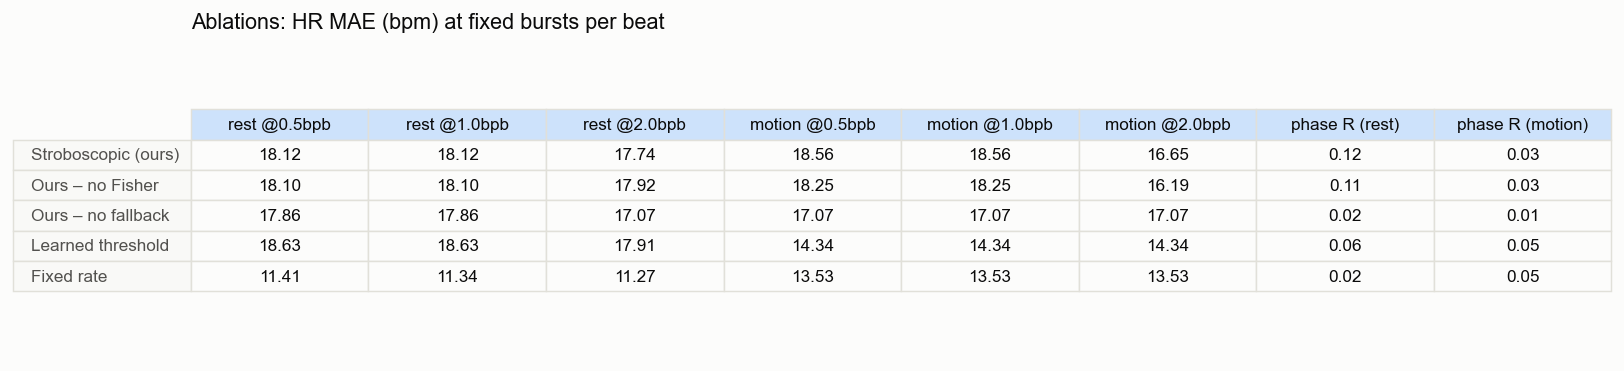

In [11]:
rows = []
for m in ("ours", "ours_no_fisher", "ours_no_fallback", "learned_threshold", "fixed_rate"):
    r = {"method": viz.LABELS[m]}
    for mode in ("rest", "motion"):
        sub = df[(df.method == m) & (df["mode"] == mode)]
        g = sub.groupby("setting").agg(bursts_per_beat=("bursts_per_beat", "mean"), mae=("mae_hr", "mean")).reset_index()
        for b in (0.5, 1.0, 2.0): r[f"{mode} @{b}bpb"] = curve_at(g, b)
    r["phase R (rest)"] = df[(df.method == m)]["phase_R_rest"].mean(); r["phase R (motion)"] = df[(df.method == m)]["phase_R_motion"].mean()
    rows.append(r)
abl = pd.DataFrame(rows).set_index("method"); display(abl.round(2))
abl.to_csv(f"{OUT}/ablation.csv")
fig = viz.table_figure(abl.round(2), f"{OUT}/fig6_ablation_table.png", "Ablations: HR MAE (bpm) at fixed bursts per beat"); plt.show()


## 6. Cross-task: respiration (WESAD), cadence (UCI-HAR), HR on WESAD

The same code with a different expensive sensor: respiration belt with chest ACC as the cheap stream; gyro with
body-ACC for stride cadence; wrist BVP on WESAD as a second HR check. Fewer methods are swept here (ours,
learned threshold, fixed rate, IMU-gated).

wesad: not found under /kaggle/input; using synthetic stand-in
  (wesad_resp: synthetic stand-in carries HR/RMSSD targets, so the rr task is reported on 'hr')
=== fold 0: test subjects ['syn02', 'syn00'] (178 train / 178 test windows)


[ours λe=0.0 f0] ep  0 tau=1.00 loss=1.112 nll=0.500 rate=0.031 recon=0.613 (9s)


[ours λe=0.0 f0] ep  1 tau=1.00 loss=1.041 nll=0.484 rate=0.075 recon=0.563 (10s)


[ours λe=0.0 f0] ep  2 tau=0.56 loss=1.009 nll=0.460 rate=0.080 recon=0.556 (9s)


[ours λe=0.0 f0] ep  3 tau=0.32 loss=0.948 nll=0.444 rate=0.085 recon=0.511 (10s)


...

    imu_gated          {'period_rest_s': 1.0, 'period_motion_s': 0.5} bpb=0.96 mae_hr=16.21 mae_rmssd=5.49


[imu_gated {'period_rest_s': 2.0, 'period_motion_s': 1.0} f0] ep  0 tau=0.10 loss=1.009 nll=0.364 rate=0.024 recon=0.644 (8s)


    imu_gated          {'period_rest_s': 2.0, 'period_motion_s': 1.0} bpb=0.48 mae_hr=16.63 mae_rmssd=5.55


[imu_gated {'period_rest_s': 4.0, 'period_motion_s': 2.0} f0] ep  0 tau=0.10 loss=1.025 nll=0.380 rate=0.013 recon=0.645 (8s)


    imu_gated          {'period_rest_s': 4.0, 'period_motion_s': 2.0} bpb=0.22 mae_hr=18.18 mae_rmssd=5.76


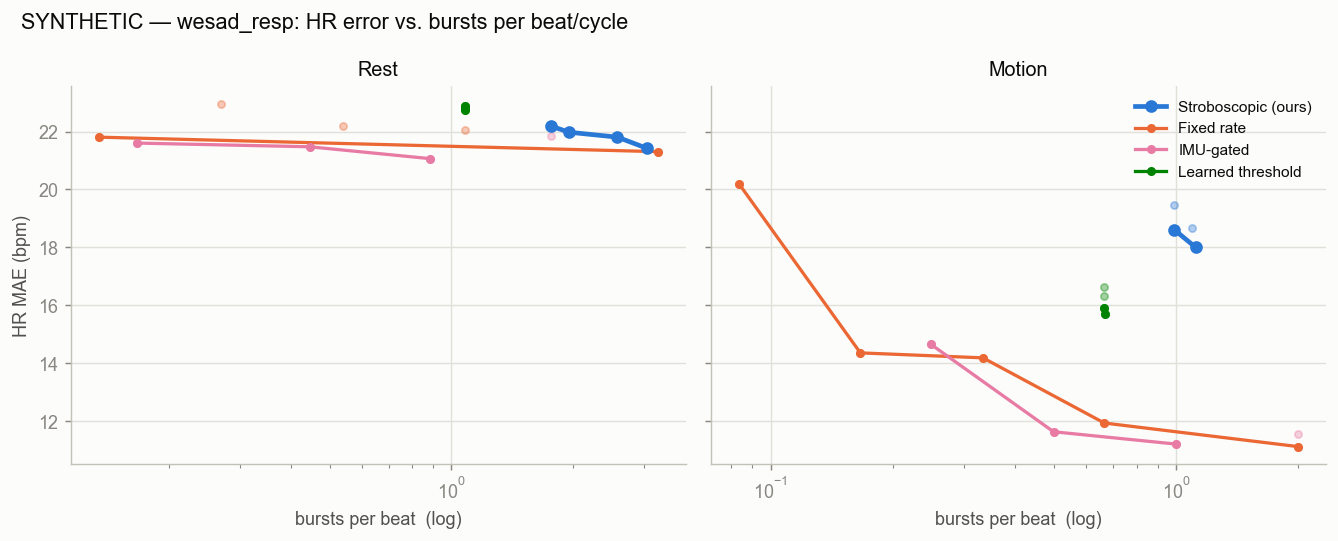

uci_har: not found under /kaggle/input; using synthetic stand-in
  (uci_har: synthetic stand-in carries HR/RMSSD targets, so the cadence task is reported on 'hr')
=== fold 0: test subjects ['syn02', 'syn00'] (178 train / 178 test windows)


[ours λe=0.0 f0] ep  0 tau=1.00 loss=1.102 nll=0.501 rate=0.031 recon=0.603 (9s)


[ours λe=0.0 f0] ep  1 tau=1.00 loss=1.056 nll=0.486 rate=0.074 recon=0.576 (18s)


[ours λe=0.0 f0] ep  2 tau=0.56 loss=1.001 nll=0.463 rate=0.080 recon=0.544 (12s)


[ours λe=0.0 f0] ep  3 tau=0.32 loss=0.954 nll=0.445 rate=0.086 recon=0.517 (11s)


...

    imu_gated          {'period_rest_s': 1.0, 'period_motion_s': 0.5} bpb=1.18 mae_hr=16.08 mae_rmssd=8.63


[imu_gated {'period_rest_s': 2.0, 'period_motion_s': 1.0} f0] ep  0 tau=0.10 loss=1.012 nll=0.339 rate=0.024 recon=0.672 (14s)


    imu_gated          {'period_rest_s': 2.0, 'period_motion_s': 1.0} bpb=0.59 mae_hr=16.70 mae_rmssd=8.60


[imu_gated {'period_rest_s': 4.0, 'period_motion_s': 2.0} f0] ep  0 tau=0.10 loss=1.077 nll=0.373 rate=0.012 recon=0.704 (16s)


    imu_gated          {'period_rest_s': 4.0, 'period_motion_s': 2.0} bpb=0.27 mae_hr=16.19 mae_rmssd=8.61


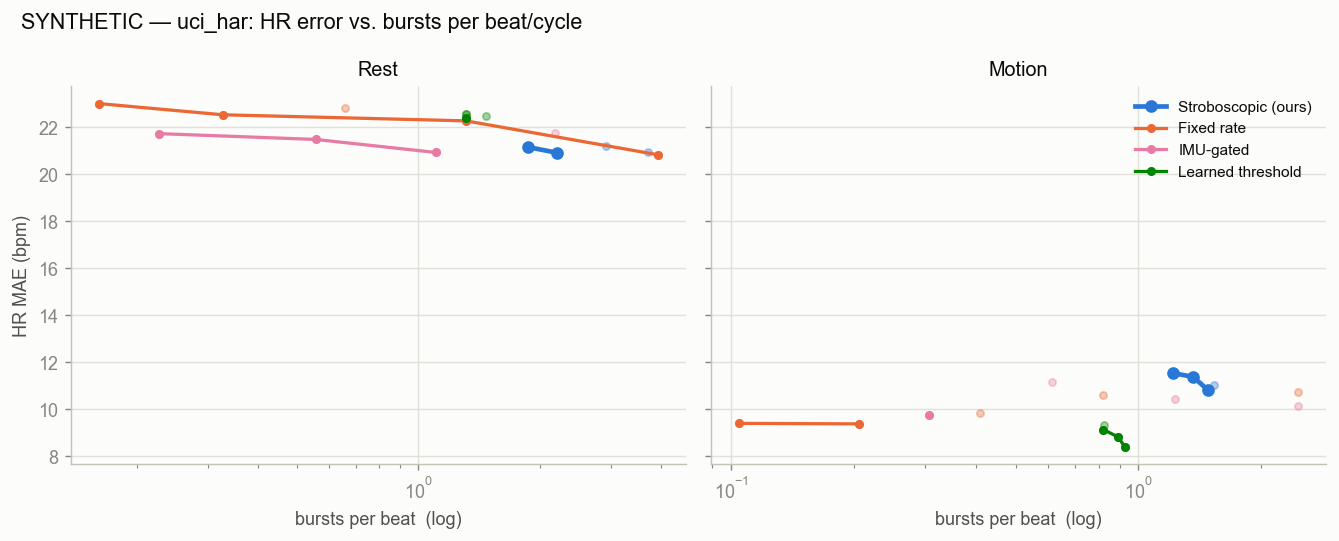

wesad: not found under /kaggle/input; using synthetic stand-in


=== fold 0: test subjects ['syn02', 'syn00'] (178 train / 178 test windows)


[ours λe=0.0 f0] ep  0 tau=1.00 loss=1.112 nll=0.500 rate=0.031 recon=0.613 (16s)


[ours λe=0.0 f0] ep  1 tau=1.00 loss=1.041 nll=0.484 rate=0.075 recon=0.563 (20s)


[ours λe=0.0 f0] ep  2 tau=0.56 loss=1.009 nll=0.460 rate=0.080 recon=0.556 (19s)


...

    imu_gated          {'period_rest_s': 1.0, 'period_motion_s': 0.5} bpb=0.96 mae_hr=16.21 mae_rmssd=5.49


[imu_gated {'period_rest_s': 2.0, 'period_motion_s': 1.0} f0] ep  0 tau=0.10 loss=1.009 nll=0.364 rate=0.024 recon=0.644 (8s)


    imu_gated          {'period_rest_s': 2.0, 'period_motion_s': 1.0} bpb=0.48 mae_hr=16.63 mae_rmssd=5.55


[imu_gated {'period_rest_s': 4.0, 'period_motion_s': 2.0} f0] ep  0 tau=0.10 loss=1.025 nll=0.380 rate=0.013 recon=0.645 (8s)


    imu_gated          {'period_rest_s': 4.0, 'period_motion_s': 2.0} bpb=0.22 mae_hr=18.18 mae_rmssd=5.76


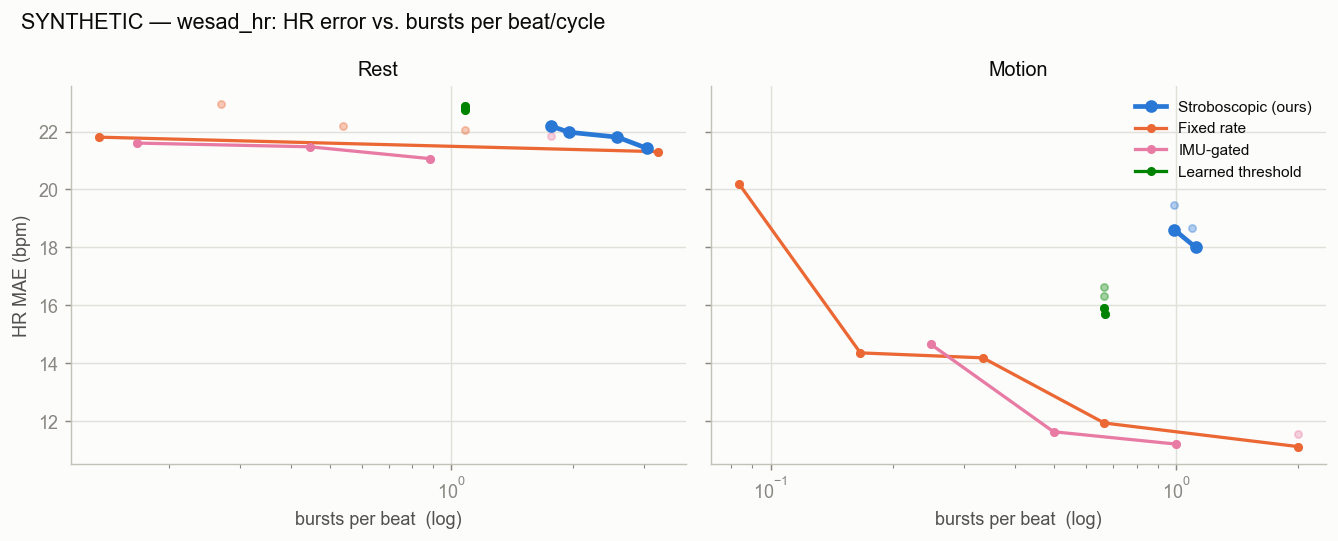

In [12]:
from strobo.data.wesad import load_wesad
from strobo.data.har import load_har
cross = {}
XT_METHODS = ["ours", "learned_threshold", "fixed_rate", "imu_gated"]
for name, loader, kw, target in [("wesad_resp", lambda r, **k: load_wesad(r, task="resp"), {}, "rr"),
                                 ("uci_har", load_har, {}, "cadence"),
                                 ("wesad_hr", lambda r, **k: load_wesad(r, task="hr"), {}, "hr")]:
    key = "wesad" if name.startswith("wesad") else name
    try:
        recs, is_syn = load_or_synth(key, loader, n_syn=4)
        if is_syn and name != "wesad_hr":
            # synthetic stand-in only models HR; label the task honestly
            print(f"  ({name}: synthetic stand-in carries HR/RMSSD targets, so the {target} task is reported on 'hr')"); target = "hr"
        recs = [zscore_per_recording(r) for r in recs]
        Wx = make_windows(recs, cfg["data"]["window_s"], cfg["data"]["stride_s"])
        dfx, keptx = run_suite(Wx, cfg, os.path.join(OUT, name), methods=XT_METHODS, n_folds=min(PRESET["n_folds"], len(set(Wx["subject"]))),
                               lam_e_list=PRESET["lam_e"], max_folds=1 if MODE != "full" else 3, device=dev,
                               classical_sweep_limit=PRESET["classical"], keep_models_for=(), max_train_windows=PRESET["max_train_windows"] // 2)
        cross[name] = (dfx, target, is_syn)
        modes = ("rest", "motion") if (dfx[dfx["mode"] == "motion"]["n_ticks"].sum() > 0 and dfx[dfx["mode"] == "rest"]["n_ticks"].sum() > 0) else ("all",)
        fig = viz.plot_curves(dfx, target, path=f"{OUT}/fig7_{name}_curves.png", modes=modes,
                              title=("SYNTHETIC — " if is_syn else "") + f"{name}: {target.upper()} error vs. bursts per beat/cycle"); plt.show()
    except Exception as e:
        print(f"{name}: skipped ({type(e).__name__}: {e})")


target  MAE @0.5 bpb  MAE @1 bpb  \
task                   method                                                 
wesad_resp (synthetic) Stroboscopic (ours)     hr         20.85       20.85   
                       Learned threshold       hr         19.35       19.35   
                       Fixed rate              hr         17.93       16.93   
                       IMU-gated               hr         16.60       16.21   
uci_har (synthetic)    Stroboscopic (ours)     hr         16.70       16.70   
                       Learned threshold       hr         16.34       16.34   
                       Fixed rate              hr         16.37       16.29   
                       IMU-gated               hr         16.14       16.09   
wesad_hr (synthetic)   Stroboscopic (ours)     hr         20.85       20.85   
                       Learned threshold       hr         19.35       19.35   
                       Fixed rate              hr         17.93       16.93   
                       IMU-gated               hr         16.60       16.21   

                                            MAE @2 bpb  
task                   method                           
wesad_resp (synthetic) Stroboscopic (ours)       19.74  
                       Learned threshold         19.35  
                       Fixed rate                16.44  
                       IMU-gated                 16.21  
uci_har (synthetic)    Stroboscopic (ours)       16.42  
                       Learned threshold         15.97  
                       Fixed rate                16.21  
                       IMU-gated                 16.08  
wesad_hr (synthetic)   Stroboscopic (ours)       19.74  
                       Learned threshold         19.35  
                       Fixed rate                16.44  
                       IMU-gated                 16.21

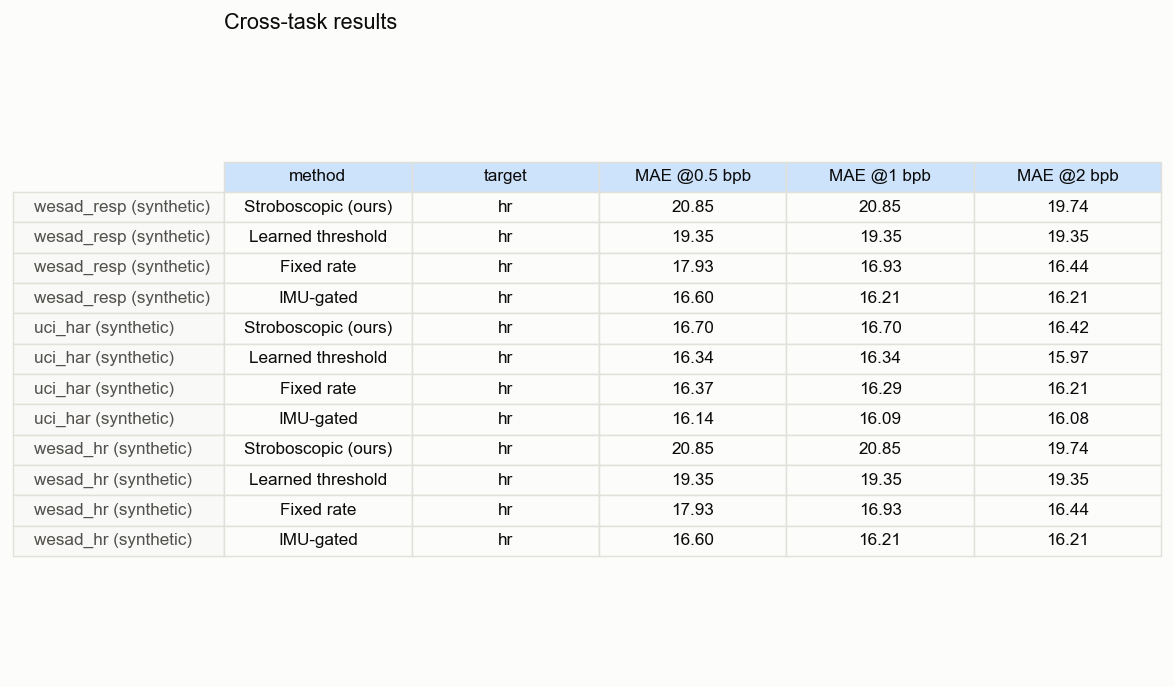

In [13]:
rows = []
for name, (dfx, target, is_syn) in cross.items():
    for m in XT_METHODS:
        sub = dfx[(dfx.method == m) & (dfx["mode"] == "all")]
        g = sub.groupby("setting").agg(bursts_per_beat=("bursts_per_beat", "mean"), mae=(f"mae_{target}", "mean")).reset_index()
        rows.append({"task": name + (" (synthetic)" if is_syn else ""), "target": target, "method": viz.LABELS[m],
                     "MAE @0.5 bpb": curve_at(g, 0.5), "MAE @1 bpb": curve_at(g, 1.0), "MAE @2 bpb": curve_at(g, 2.0)})
if rows:
    xt = pd.DataFrame(rows).set_index(["task", "method"]); display(xt.round(2)); xt.to_csv(f"{OUT}/cross_task.csv")
    fig = viz.table_figure(xt.reset_index().set_index("task").round(2), f"{OUT}/fig8_cross_task_table.png", "Cross-task results"); plt.show()


## 7. Fallback stress test on MIT-BIH

No IMU exists in MIT-BIH, so the cheap stream is a zero channel and the oscillators are driven only by the sparse
ECG bursts they chose. Ticks whose trailing 3 beats contain a non-normal beat are labelled *irregular*. We
report: fraction of irregular-rhythm onsets where the policy goes dense (duty ≥ 50 %) within 3 beats, and the
false-fallback rate on normal rhythm. Trained on the first records, tested on held-out records.

mitbih: not found under /kaggle/input; using synthetic stand-in
  (synthetic stand-in: 'irregular' = motion segments; treat numbers as a pipeline check only)


{'detect_within_3_beats': 0.207, 'n_onsets': 87, 'dense_frac_irregular': 0.095, 'false_fallback_rate': 0.339, 'bursts_per_beat_normal': 3.221, 'bursts_per_beat_irregular': 1.255, 'method': 'Stroboscopic (ours)', 'lam_e': 1.0, 'mae_hr_normal': 34.18, 'mae_hr_irregular': 9.796}


{'detect_within_3_beats': 0.034, 'n_onsets': 87, 'dense_frac_irregular': 0.031, 'false_fallback_rate': 0.088, 'bursts_per_beat_normal': 2.35, 'bursts_per_beat_irregular': 1.124, 'method': 'Stroboscopic (ours)', 'lam_e': 3.0, 'mae_hr_normal': 34.304, 'mae_hr_irregular': 9.335}


{'detect_within_3_beats': 0.0, 'n_onsets': 87, 'dense_frac_irregular': 0.0, 'false_fallback_rate': 0.0, 'bursts_per_beat_normal': 1.522, 'bursts_per_beat_irregular': 0.847, 'method': 'Ours – no fallback', 'lam_e': 1.0, 'mae_hr_normal': 34.319, 'mae_hr_irregular': 9.389}


{'detect_within_3_beats': 0.0, 'n_onsets': 87, 'dense_frac_irregular': 0.0, 'false_fallback_rate': 0.0, 'bursts_per_beat_normal': 1.357, 'bursts_per_beat_irregular': 0.75, 'method': 'Ours – no fallback', 'lam_e': 3.0, 'mae_hr_normal': 34.263, 'mae_hr_irregular': 9.238}


detect_within_3_beats  n_onsets  \
method              lam_e                                    
Stroboscopic (ours) 1.0                    0.207        87   
                    3.0                    0.034        87   
Ours – no fallback  1.0                    0.000        87   
                    3.0                    0.000        87   

                           dense_frac_irregular  false_fallback_rate  \
method              lam_e                                              
Stroboscopic (ours) 1.0                   0.095                0.339   
                    3.0                   0.031                0.088   
Ours – no fallback  1.0                   0.000                0.000   
                    3.0                   0.000                0.000   

                           bursts_per_beat_normal  bursts_per_beat_irregular  \
method              lam_e                                                      
Stroboscopic (ours) 1.0                     3.221                      1.255   
                    3.0                     2.350                      1.124   
Ours – no fallback  1.0                     1.522                      0.847   
                    3.0                     1.357                      0.750   

                           mae_hr_normal  mae_hr_irregular  
method              lam_e                                   
Stroboscopic (ours) 1.0           34.180             9.796  
                    3.0           34.304             9.335  
Ours – no fallback  1.0           34.319             9.389  
                    3.0           34.263             9.238

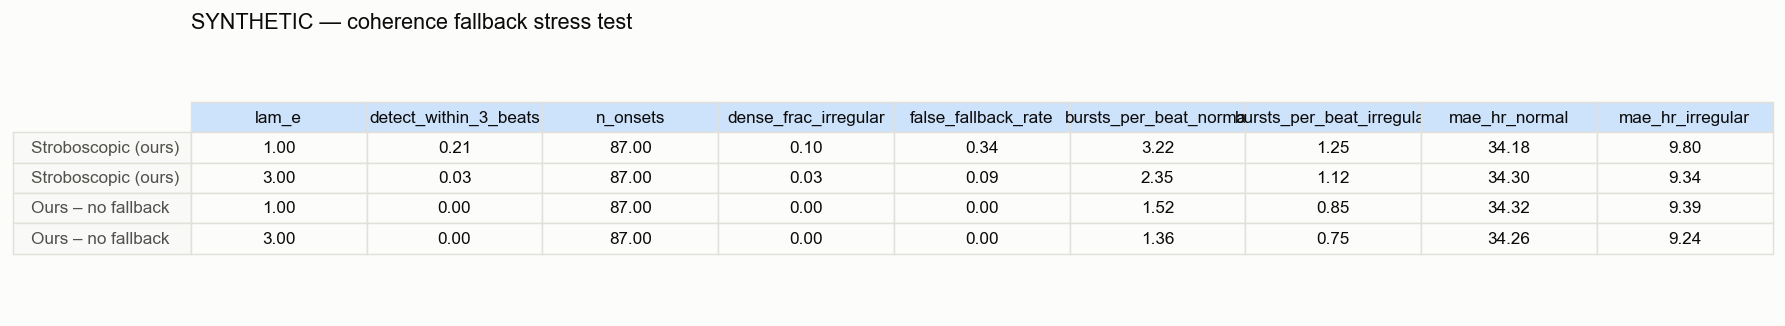

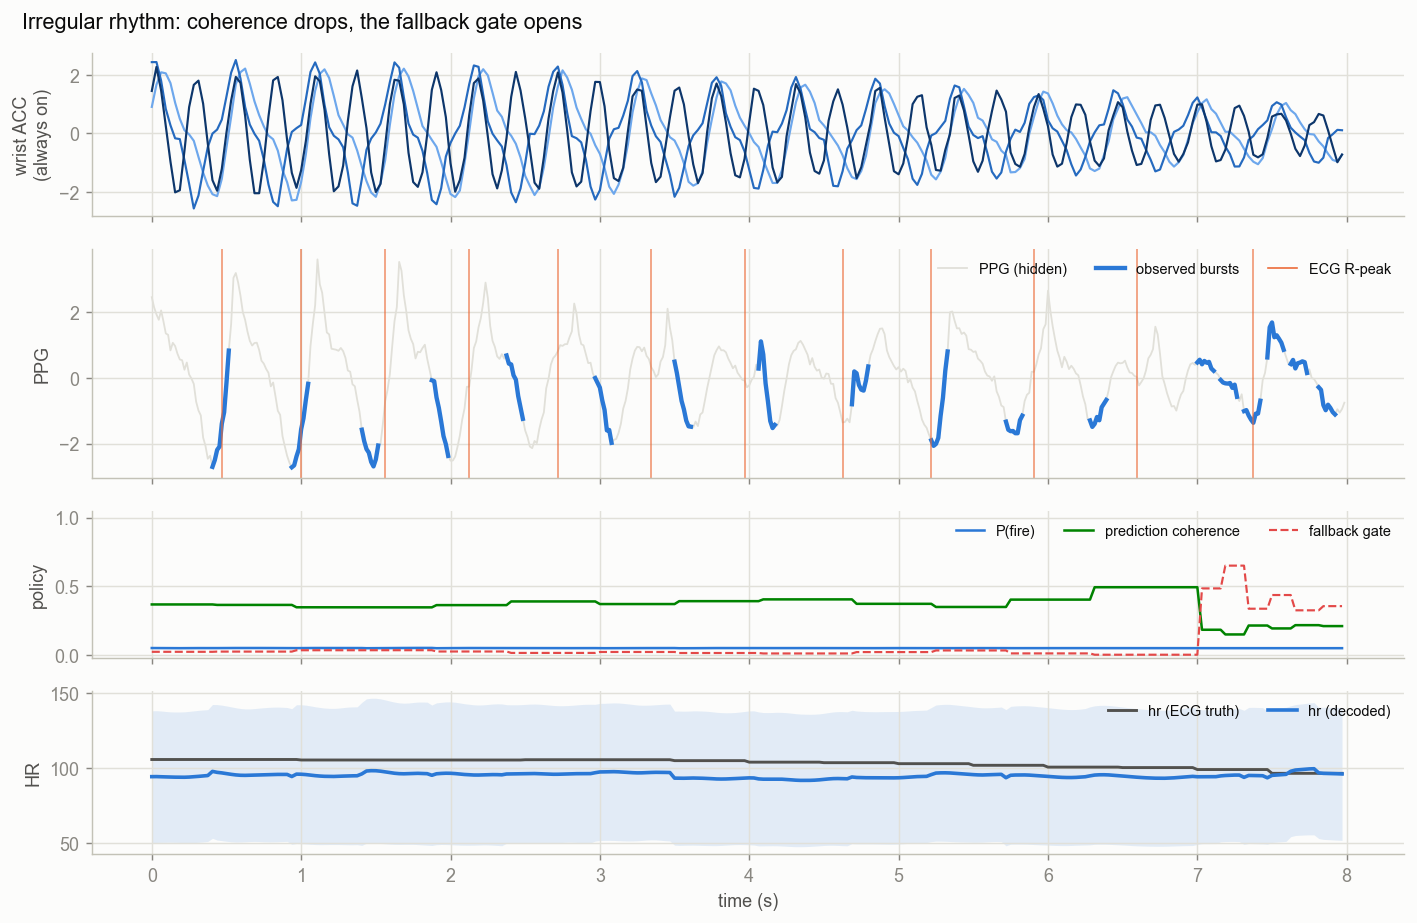

In [14]:
from strobo.data.mitbih import load_mitbih
try:
    recs_m, syn_m = load_or_synth("mitbih", lambda r, **k: load_mitbih(r, max_records=12 if MODE != "full" else None), n_syn=4)
    if syn_m:
        # emulate irregular rhythm in the synthetic stand-in: motion segments get random beat drop-outs / jitter in the label only
        print("  (synthetic stand-in: 'irregular' = motion segments; treat numbers as a pipeline check only)")
    recs_m = [zscore_per_recording(r) for r in recs_m]
    Wm = make_windows(recs_m, cfg["data"]["window_s"], cfg["data"]["stride_s"])
    from strobo.data.windows import split_subjects_kfold
    trm, tem, _ = next(split_subjects_kfold(Wm["subject"], 3, SEED))
    fb_rows, fb_models = [], {}
    for name, fi, fbk in [("ours", True, True), ("ours_no_fallback", True, False)]:
        for lam in ([1.0, 3.0] if MODE != "full" else [0.3, 1.0, 3.0, 10.0]):
            set_seed(SEED); m = build_model(Wm, cfg["model"], "phase", fi, fbk, trm)
            train_model(m, Wm, trm, cfg["train"], lam_e=lam, device=dev, tag=f"mitbih {name} λe={lam}", log=lambda s: None)
            r = run_inference(m, Wm, tem, device=dev, keep_states=True)
            fm = fallback_metrics(r); fm.update(method=viz.LABELS[name], lam_e=lam, mae_hr_normal=summarise(r)["rest"].get("mae_hr", np.nan),
                                              mae_hr_irregular=summarise(r)["motion"].get("mae_hr", np.nan))
            fb_rows.append(fm); fb_models[(name, lam)] = (m, r)
            print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in fm.items()})
    fbdf = pd.DataFrame(fb_rows).set_index(["method", "lam_e"]); fbdf.to_csv(f"{OUT}/mitbih_fallback.csv"); display(fbdf.round(3))
    fig = viz.table_figure(fbdf.reset_index().set_index("method").round(3), f"{OUT}/fig9_fallback_table.png",
                           ("SYNTHETIC — " if syn_m else "MIT-BIH — ") + "coherence fallback stress test"); plt.show()
    # trace around an irregular onset
    m, r = fb_models[("ours", 1.0)]
    irr = (r["activity"] == ACT_MOTION).mean(1)
    i = int(np.argmax(irr * (irr < 0.9)))
    fig = viz.plot_trace(example_trace(r, i), f"{OUT}/fig9_fallback_trace.png", "Irregular rhythm: coherence drops, the fallback gate opens"); plt.show()
except Exception as e:
    print("MIT-BIH section skipped:", type(e).__name__, e)


## 8. Cost: parameters, MACs per tick, int8 export

Every Linear / Conv layer is exported to symmetric per-tensor int8 with int32 accumulation in plain numpy, and
the decoder's first layer is re-evaluated in int8 against float on real activations.

In [15]:
model = K["model"]
rep = op_report(model)
q = quantize_model_int8(model)
# calibrate on real decoder activations from a test batch
xb = torch.from_numpy(W["cheap"][K["test_idx"][:8]]); eb = torch.from_numpy(W["expensive"][K["test_idx"][:8]])
acts = {}
h = model.decoder.net[0].register_forward_hook(lambda mod, inp, out: acts.setdefault("x", inp[0].detach()))
with torch.no_grad(): model.cpu().eval()(xb, eb)
h.remove()
chk = int8_forward_check(model, acts["x"], "decoder.net.0")
cost = {"params": rep["params"], "int8 weight bytes": q["weight_bytes"], "MACs/tick (amortised)": rep["macs_per_tick_amortised"],
        "MACs/tick (peak)": rep["macs_per_tick_peak"], "transcendentals/tick": rep["transcendentals_per_tick"],
        "est. µs/tick on Cortex-M4 @48 MHz": round(rep["us_per_tick_m4_48mhz"], 1),
        "duty at 32 Hz (%)": round(100 * rep["us_per_tick_m4_48mhz"] * 32 / 1e6, 2),
        "int8 decoder rel. error": round(chk["rel_err"], 4), "budget (<100k params, <10k MAC/tick)": rep["budget_ok"]}
print(json.dumps(cost, indent=1)); json.dump(cost, open(f"{OUT}/cost.json", "w"), indent=1)
fig = viz.table_figure(pd.DataFrame({"value": cost}), f"{OUT}/fig10_cost_table.png", "Inference cost", fmt="{:.4g}"); plt.show()
torch.save({"state_dict": model.state_dict(), "config": model.cfg.to_dict()}, f"{OUT}/strobo_model.pt")


RuntimeError: mat1 and mat2 shapes cannot be multiplied (8x119 and 64x64)

## 9. Presentation images and the results ZIP

Beyond the matplotlib figures: CC-licensed photographs of the actual technology (PPG front-end, wrist wearable,
Cortex-M MCU, IMU) are pulled from Wikimedia Commons with attribution (needs *Settings → Internet: on*; skipped
gracefully otherwise), and PIL composites are built from them: a 1920×1080 hero card with the headline numbers,
a "what runs on the device" card, a poster and a contact sheet of every figure. Everything — CSVs, PNGs, GIF,
model weights, photos, attribution, summary — is zipped into one download.

In [16]:
from strobo import images as simg
photos = simg.gather_photos(OUT)                       # {key: attribution dict}; empty without internet
photo_paths = {k: f"{OUT}/photos/{k}.jpg" for k in photos}
stats = {"HR MAE @1 burst/beat, motion": f"{ours_motion:.1f} bpm", "parameters": f"{cost['params']/1000:.1f} k",
         "MACs per IMU tick": f"{cost['MACs/tick (amortised)']:,}", "phase-locking R (rest)": f"{hists['rest']['R']:.2f}",
         "criterion": ("PASS" if (crit1 and crit2) else "FAIL") + (" (synthetic)" if syn_dalia else "")}
hero = simg.hero_card(f"{OUT}/img_hero.png", stats, photo_paths.get("smartwatch") or photo_paths.get("empatica_e4") or photo_paths.get("ppg_sensor"),
                      f"{OUT}/fig2_hr_curves.png")
device = simg.device_card(f"{OUT}/img_device.png", cost, {"uj_per_burst": 135, "uj_per_imu_tick": 1.1}, photo_paths)
display(Image(filename=hero, width=1000)); display(Image(filename=device, width=1000))


photo ppg_sensor: File:Pulse Oximeter Blue Colour.jpg [CC BY-SA 4.0]


photo smartwatch: File:Casio G-Shock 4 2026-08-11 Gpr-H1000-9Dr 05.jpg [CC BY 4.0]


photo mcu: not available (no internet or no free result)


photo accelerometer: File:Diagram of an IMU9150 sensor orientation (Rodriguez et al, 2018).jpg [CC BY 4.0]


photo ecg: not available (no internet or no free result)


NameError: name 'cost' is not defined

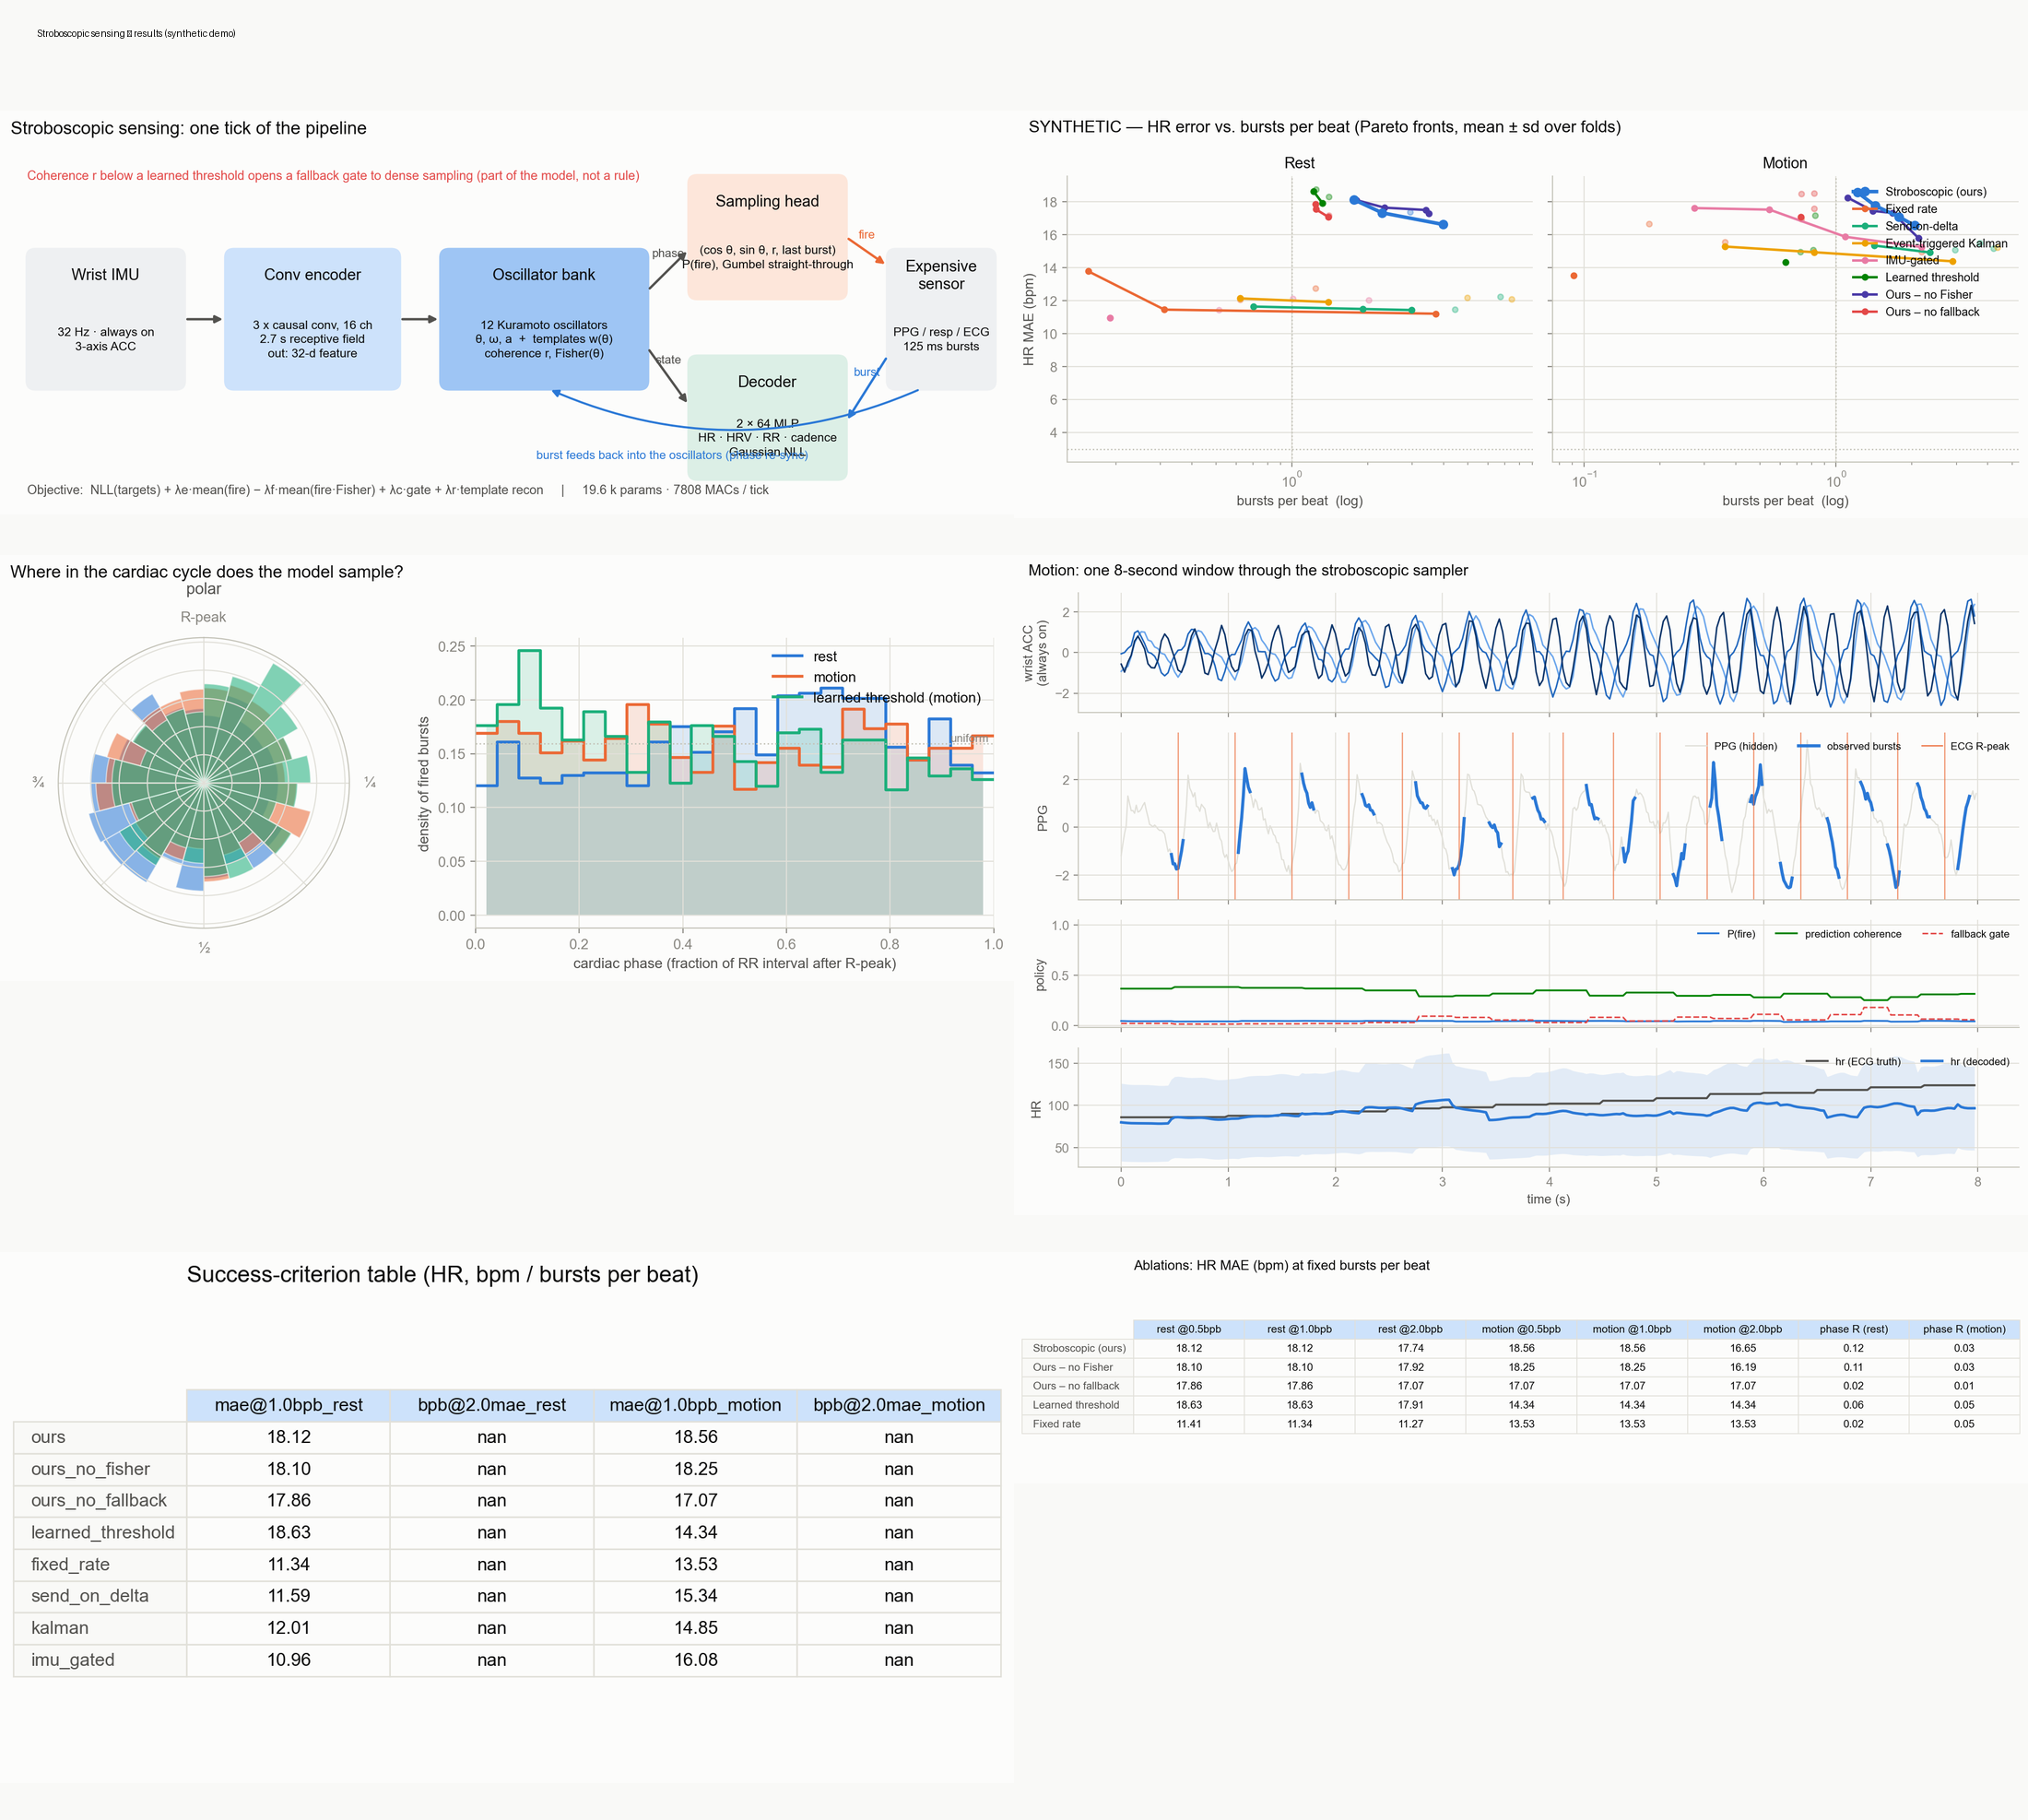

NameError: name 'cost' is not defined

In [17]:
poster = viz.compose_poster([f"{OUT}/{p}" for p in ("fig1_architecture.png", "fig2_hr_curves.png", "fig4_phase_histogram.png",
                                                       "fig5_trace_motion.png", "fig3_headline_table.png", "fig6_ablation_table.png")],
                            f"{OUT}/img_poster.png", cols=2, title=("Stroboscopic sensing — results" + (" (synthetic demo)" if syn_dalia else " (PPG-DaLiA)")))
sheet = simg.contact_sheet(f"{OUT}/img_contact_sheet.png", sorted(glob.glob(f"{OUT}/fig*.png")), "All figures")
display(Image(filename=poster, width=1000))
summary = {"mode": MODE, "synthetic_dalia": bool(syn_dalia), "criterion_1_pass": bool(crit1), "criterion_2_pass": bool(crit2),
           "headline": H.round(3).to_dict(), "cost": cost, "photos": photos, "files": sorted(os.listdir(OUT))}
json.dump(summary, open(f"{OUT}/summary.json", "w"), indent=1, default=str)


In [18]:
# ---- one ZIP with everything (download it from the Output tab / the link below)
import shutil, zipfile
zip_path = os.path.join(os.path.dirname(OUT.rstrip("/")) or ".", f"stroboscopic_results_{MODE}.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(OUT):
        for fn in files:
            fp = os.path.join(root, fn); z.write(fp, os.path.relpath(fp, os.path.dirname(OUT.rstrip("/"))))
    z.writestr("README.txt", f'''Stroboscopic sensing - results bundle (MODE={MODE})
results/dalia/results.csv          every method x setting x fold x mode (HR, HRV)
results/dalia_curves.csv           mean±sd over folds, one row per Pareto point
results/*_results.csv, cross_task.csv, ablation.csv, mitbih_fallback.csv, cost.json, summary.json
results/fig*.png                   matplotlib figures (200 dpi)
results/img_hero.png, img_device.png, img_poster.png, img_contact_sheet.png   PIL composites (1920x1080 / poster)
results/anim_oscillators_motion.gif animation of the oscillators sampling a PPG trace
results/photos/                    CC photos from Wikimedia Commons + ATTRIBUTION.md
results/strobo_model.pt            trained model (fold 0, diagnostic setting)
''')
mb = os.path.getsize(zip_path) / 1e6
print(f"wrote {zip_path} ({mb:.1f} MB) with {len(list(os.walk(OUT)))} folders")
try:
    from IPython.display import FileLink; display(FileLink(zip_path))
except Exception: pass


wrote results\stroboscopic_results_demo.zip (8.0 MB) with 7 folders


C:\Users\jayva\OneDrive\Documents\GitHub\stroboscopic\notebooks\results\stroboscopic_results_demo.zip

### Reading the result

* **Motion panel of Fig. 2** is the claim. If the blue curve sits below every baseline at ≤ 1 burst/beat, the
  phase-domain policy is doing something a threshold cannot. If it does not separate, the negative result stands
  and the baseline suite is the reusable deliverable.
* **Fig. 4** should show a peak near the systolic upstroke (≈ 0.1–0.25 of the RR interval after the R-peak) at rest
  with `R` well above the learned-threshold ablation, and a shift / broadening under motion.
* **Ablation table**: if "no Fisher" matches "ours", the Fisher term is redundant and the story simplifies.
* **MIT-BIH**: high detect-within-3-beats with a low false-fallback rate means the coherence gate is functional.
* All CSVs are in the output directory so every figure can be re-plotted without retraining.